# Data Preprocessing (Multiclass Without Cutting)
Load raw data, visualize, map labels, remove cutting (label 4), chunk windows, normalize, and train multiclass BiLSTM.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Swin documents/COS40007-Project/backend')

# Importing libraries

In [2]:
from types import SimpleNamespace
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from utils.seed import set_seed
from utils.device import get_device
from data.preprocessing import (
    create_windows,
    clean_features,
    normalize_features,
    get_feature_columns,
 )
from data.motion_dataset import MotionDataset

# Config (no Hydra)
seed = 42
device = get_device("auto")
set_seed(seed)

sensor_types = ["Segment Velocity", "Segment Acceleration"]
video_suffix = None
window_size = 60
stride = 30
batch_size = 32
num_workers = 0
val_split = 0.2


# Read data 

In [3]:
print("[phase=data] loading P1 + P2 datasets")
DATA_DIR = PROJECT_ROOT / "output_data"

# P1 source
p1_dfs = [
    pd.read_csv(DATA_DIR / "P1_boning.csv"),
    pd.read_csv(DATA_DIR / "P1_slicing.csv"),
]
p1_raw_df = pd.concat(p1_dfs, ignore_index=True)

# P2 source
p2_dfs = [
    pd.read_csv(DATA_DIR / "P2_boning.csv"),
    pd.read_csv(DATA_DIR / "P2_slicing.csv"),
]
p2_raw_df = pd.concat(p2_dfs, ignore_index=True)

# Keep velocity + acceleration only
p1_raw_df = p1_raw_df[p1_raw_df["sensor_type"].isin(sensor_types)]
p2_raw_df = p2_raw_df[p2_raw_df["sensor_type"].isin(sensor_types)]

# Optional video suffix filter
if video_suffix is not None:
    p1_raw_df = p1_raw_df[p1_raw_df["video_id"].str.endswith(video_suffix)]
    p2_raw_df = p2_raw_df[p2_raw_df["video_id"].str.endswith(video_suffix)]

def merge_velocity_and_acceleration(df):
    vel_df = df[df["sensor_type"] == "Segment Velocity"].copy()
    acc_df = df[df["sensor_type"] == "Segment Acceleration"].copy()

    if vel_df.empty or acc_df.empty:
        raise ValueError("Both Segment Velocity and Segment Acceleration rows are required.")

    base_feature_cols = get_feature_columns(vel_df)

    id_cols = [
        c for c in ["video_id", "Frame", "Label", "person_id", "activity_type", "knife_sharpness_score"]
        if c in vel_df.columns
    ]

    vel_df = vel_df[id_cols + base_feature_cols].rename(
        columns={c: f"{c}_vel" for c in base_feature_cols}
    )
    acc_df = acc_df[["video_id", "Frame"] + base_feature_cols].rename(
        columns={c: f"{c}_acc" for c in base_feature_cols}
    )

    merged_df = vel_df.merge(
        acc_df,
        on=["video_id", "Frame"],
        how="inner",
        validate="one_to_one",
    )
    return merged_df, base_feature_cols

p1_df, base_feature_cols = merge_velocity_and_acceleration(p1_raw_df)
p2_df, _ = merge_velocity_and_acceleration(p2_raw_df)

velocity_feature_cols = [f"{c}_vel" for c in base_feature_cols]
acceleration_feature_cols = [f"{c}_acc" for c in base_feature_cols]
feature_cols = velocity_feature_cols + acceleration_feature_cols

assert p1_df["Label"].nunique() > 1, "Only one class left after filtering - train/val invalid"
assert p2_df["Label"].nunique() > 1, "Only one class left after filtering - test invalid"

print(f"[phase=data] p1_rows={len(p1_df)} p2_rows={len(p2_df)}")
print(f"[phase=data] velocity_features={len(velocity_feature_cols)} acceleration_features={len(acceleration_feature_cols)} total_features={len(feature_cols)}")
p1_df.head()


[phase=data] loading P1 + P2 datasets


C:\Users\PCPV\AppData\Local\Temp\ipykernel_2200\3268270065.py:6: DtypeWarning: Columns (0: Label) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_boning.csv"),
C:\Users\PCPV\AppData\Local\Temp\ipykernel_2200\3268270065.py:7: DtypeWarning: Columns (0: Label) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_slicing.csv"),


[phase=data] p1_rows=266924 p2_rows=208908
[phase=data] velocity_features=66 acceleration_features=66 total_features=132


,video_id,Frame,Label,person_id,activity_type,knife_sharpness_score,L5 x_vel,L5 y_vel,L5 z_vel,L3 x_vel,...,Left Upper Leg z_acc,Left Lower Leg x_acc,Left Lower Leg y_acc,Left Lower Leg z_acc,Left Foot x_acc,Left Foot y_acc,Left Foot z_acc,Left Toe x_acc,Left Toe y_acc,Left Toe z_acc
0,MVN-J-Boning-64-001,0,4,P1,boning,64,0.016263,-0.095142,0.221275,0.016263,...,-1.463229,-1.665037,-2.060481,-1.485525,-2.185359,-1.194785,-1.663235,-2.185359,-1.194785,-1.663235
1,MVN-J-Boning-64-001,1,4,P1,boning,64,0.001253,-0.126477,0.188341,-0.007620,...,-1.230812,-0.752149,-2.689504,-1.314239,-1.060466,-1.162565,-1.845591,-1.064713,-1.147108,-1.845636
2,MVN-J-Boning-64-001,2,4,P1,boning,64,-0.013758,-0.157811,0.155406,-0.031503,...,-1.454299,0.183840,-2.178955,-1.321744,-0.220440,-1.530509,-1.658241,-0.227187,-1.514522,-1.657987
3,MVN-J-Boning-64-001,3,4,P1,boning,64,-0.022041,-0.178102,0.134543,-0.045098,...,-1.521032,0.540981,-0.951495,-1.324380,-0.175790,-1.007643,-1.326566,-0.091278,-0.986575,-1.316862
4,MVN-J-Boning-64-001,4,4,P1,boning,64,-0.020406,-0.179536,0.134429,-0.042620,...,-0.523328,0.754778,-0.402592,-0.509365,0.347853,-0.509991,-0.538392,0.335083,-0.493518,-0.537629


# Visualize Data (Optional)

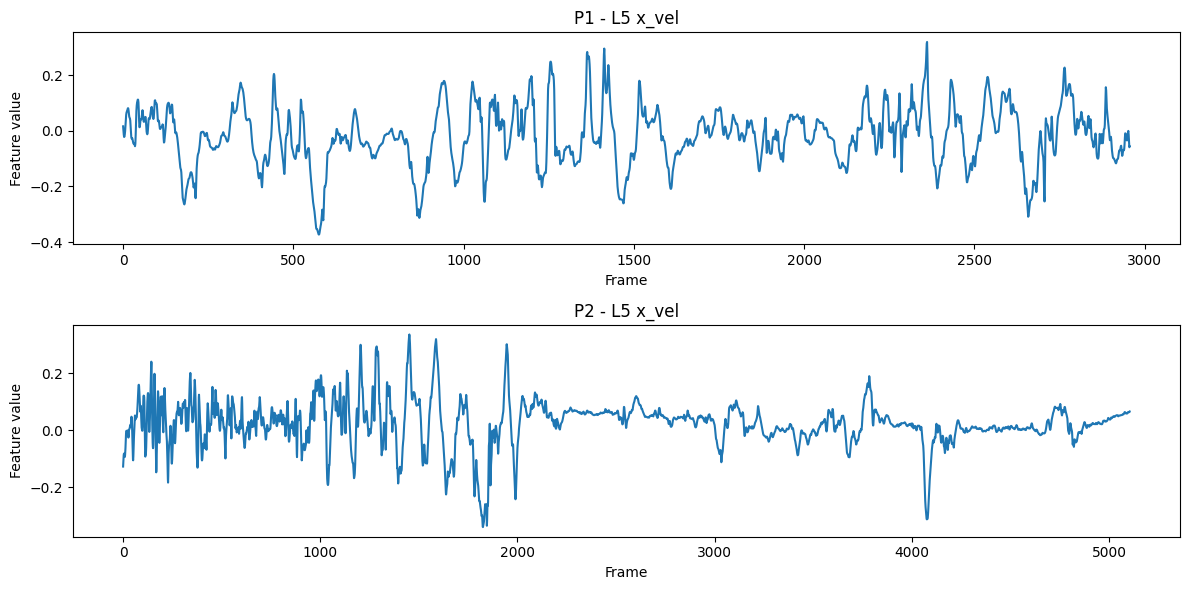

In [4]:
import matplotlib.pyplot as plt

# choose feature to visualize
feature_name = "L5 x_vel"   # change to any feature column

# optionally select one video from each dataset
p1_sample = p1_df[p1_df["video_id"] == p1_df["video_id"].iloc[0]]
p2_sample = p2_df[p2_df["video_id"] == p2_df["video_id"].iloc[0]]

# frame index
x1 = range(len(p1_sample))
x2 = range(len(p2_sample))

# create horizontal stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# P1 plot
axes[0].plot(x1, p1_sample[feature_name])
axes[0].set_title(f"P1 - {feature_name}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Feature value")

# P2 plot
axes[1].plot(x2, p2_sample[feature_name])
axes[1].set_title(f"P2 - {feature_name}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Feature value")

plt.tight_layout()
plt.show()

# Process Data: Split Train/Test/Val

In [5]:
import pandas as pd

print("[phase=data] Unique labels and their counts per activity:")

# 1. Combine both datasets to get the overall count
combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# 2. Group by activity_type and Label to calculate counts
overall_label_counts = combined_df.groupby(
    ['Label']
).size().reset_index(name='Count')

# 3. Print the detailed breakdown
print(overall_label_counts.to_string(index=False))


[phase=data] Unique labels and their counts per activity:
                    Label  Count
                        0  62948
                        1  13102
                        2  43149
                        3  16984
                        4 213592
                        5  34193
                        6   7162
                        7   4838
                        8  16325
                        0    529
                        1   1566
                        2    587
             2 - Steeling   1469
                        3    479
             3 - Reaching   3282
                        4   5540
              4 - Cutting  24550
                        5    117
              5 - Slicing  18779
7 - Placing/ Manipulating    787
             8 - Dropping   5854


# Relabel

In [6]:
print("[phase=data] Cleaning inconsistent labels and removing cutting (label=4)")

label_mapping = {
    '0- Idle': 0,
    '0 - Idle': 0,
    '1- Walking': 1,
    '1 - Walking': 1,
    '2- Steeling': 2,
    '2 - Steeling': 2,
    '3- Reaching': 3,
    '3 - Reaching': 3,
    '4- Cutting': 4,
    '4 - Cutting': 4,
    '4 - Cutting (Big Pieces)': 4,
    '4 - Cutting (Big Piece)': 4,
    '4- Cutting (big piece)': 4,
    '4 - Cutting (offloading bone from Carcass)': 4,
    '5- Dropping': 8,
    '5 - Dropping': 8,
    '5 - Slicing': 5,
    '6 - Pulling': 6,
    '7 - Placing/ Manipulating': 7,
    '8 - Dropping': 8,
}

for df in [p1_df, p2_df]:
    df['Label'] = df['Label'].replace(label_mapping)
    df['Label'] = pd.to_numeric(df['Label'], errors='coerce')

for df in [p1_df, p2_df]:
    boning_mask = df['activity_type'].str.lower().eq('boning')
    df.loc[boning_mask & (df['Label'] == 5), 'Label'] = 8

for df in [p1_df, p2_df]:
    if df['Label'].isna().any():
        print("[warning] Found non-numeric labels after mapping")
    df['Label'] = df['Label'].astype('int64')

# Remove cutting class (label 4) for multiclass training on remaining labels
p1_df = p1_df[p1_df['Label'] != 4].copy()
p2_df = p2_df[p2_df['Label'] != 4].copy()

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)
class_labels_raw = sorted(combined_df['Label'].unique().tolist())

assert 4 not in class_labels_raw, "Cutting label 4 should be removed"
assert len(class_labels_raw) > 1, "Need at least 2 classes after removing cutting"

print("[phase=data] Removed cutting label (4); keeping original remaining label IDs")
print(f"[phase=data] class_labels={class_labels_raw}")

overall_label_counts = combined_df.groupby(['activity_type', 'Label']).size().reset_index(name='Count')
print("\n[phase=data] label counts by activity (excluding cutting):")
print(overall_label_counts.to_string(index=False))

[phase=data] Cleaning inconsistent labels and removing cutting (label=4)
[phase=data] Removed cutting label (4); keeping original remaining label IDs
[phase=data] class_labels=[0, 1, 2, 3, 5, 6, 7, 8]

[phase=data] label counts by activity (excluding cutting):
activity_type  Label  Count
       boning      0  54101
       boning      1  13218
       boning      2  36588
       boning      3  11699
       boning      8  11534
      slicing      0   9376
      slicing      1   1450
      slicing      2   8617
      slicing      3   9046
      slicing      5  41555
      slicing      6   7162
      slicing      7   5625
      slicing      8  22179


# Feature Engineering

In [7]:
import numpy as np
import pandas as pd

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# Build segment list from base xyz feature names (e.g., "L5 x")
segment_names = []
for col in base_feature_cols:
    segment_name, axis = col.rsplit(" ", 1)
    if axis == "x":
        segment_names.append(segment_name)

# 22 velocity magnitude features + 22 acceleration magnitude features
for seg in segment_names:
    vx_col, vy_col, vz_col = f"{seg} x_vel", f"{seg} y_vel", f"{seg} z_vel"
    ax_col, ay_col, az_col = f"{seg} x_acc", f"{seg} y_acc", f"{seg} z_acc"

    vel_mag_col = f"{seg}_vel_mag"
    acc_mag_col = f"{seg}_acc_mag"

    combined_df[vel_mag_col] = np.sqrt(
        combined_df[vx_col] ** 2 + combined_df[vy_col] ** 2 + combined_df[vz_col] ** 2
    )
    combined_df[acc_mag_col] = np.sqrt(
        combined_df[ax_col] ** 2 + combined_df[ay_col] ** 2 + combined_df[az_col] ** 2
    )

velocity_mag_feature_cols = [f"{seg}_vel_mag" for seg in segment_names]
acceleration_mag_feature_cols = [f"{seg}_acc_mag" for seg in segment_names]

# 1 total body energy feature: sum of squared x,y,z over all joints (velocity + acceleration)
energy_terms = []
for seg in segment_names:
    energy_terms.extend([
        combined_df[f"{seg} x_vel"] ** 2,
        combined_df[f"{seg} y_vel"] ** 2,
        combined_df[f"{seg} z_vel"] ** 2,
        combined_df[f"{seg} x_acc"] ** 2,
        combined_df[f"{seg} y_acc"] ** 2,
        combined_df[f"{seg} z_acc"] ** 2,
    ])
combined_df["total_body_energy"] = np.sum(np.column_stack(energy_terms), axis=1)

# Final training features: 22 + 22 + 1 = 45
feature_cols = velocity_mag_feature_cols + acceleration_mag_feature_cols + ["total_body_energy"]

print("[phase=features] Using engineered features by request")
print(f"Velocity magnitude features: {len(velocity_mag_feature_cols)}")
print(f"Acceleration magnitude features: {len(acceleration_mag_feature_cols)}")
print("Total body energy features: 1")
print(f"Total training features: {len(feature_cols)}")
print("Sample features:", feature_cols[:5], "...", feature_cols[-3:])

[phase=features] Using engineered features by request
Velocity magnitude features: 22
Acceleration magnitude features: 22
Total body energy features: 1
Total training features: 45
Sample features: ['L5_vel_mag', 'L3_vel_mag', 'T12_vel_mag', 'T8_vel_mag', 'Neck_vel_mag'] ... ['Left Foot_acc_mag', 'Left Toe_acc_mag', 'total_body_energy']


In [8]:
print(p1_df["Label"].dtype)

int64


# Dynamic Windows by Label Transitions

Detect activity label changes (without groupby), count frames per label, visualize one sample, then build dynamic windows.

In [9]:
import pandas as pd

print("[phase=runs] Building contiguous label runs by video_id + label change (no groupby)")

combined_df = combined_df.sort_values(["video_id", "Frame"]).reset_index(drop=True)

runs = []
frame_counts = {}
run_counts = {}

start_idx = 0
current_video = combined_df.loc[0, "video_id"]
current_label = int(combined_df.loc[0, "Label"])

for i in range(len(combined_df)):
    label_i = int(combined_df.loc[i, "Label"])
    frame_counts[label_i] = frame_counts.get(label_i, 0) + 1

for i in range(1, len(combined_df)):
    video_i = combined_df.loc[i, "video_id"]
    label_i = int(combined_df.loc[i, "Label"])

    is_boundary = (video_i != current_video) or (label_i != current_label)

    if is_boundary:
        end_idx = i - 1
        start_frame = int(combined_df.loc[start_idx, "Frame"])
        end_frame = int(combined_df.loc[end_idx, "Frame"])
        run_length = end_idx - start_idx + 1

        runs.append({
            "video_id": current_video,
            "label": current_label,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "run_length": run_length,
        })

        run_counts[current_label] = run_counts.get(current_label, 0) + 1

        start_idx = i
        current_video = video_i
        current_label = label_i

end_idx = len(combined_df) - 1
start_frame = int(combined_df.loc[start_idx, "Frame"])
end_frame = int(combined_df.loc[end_idx, "Frame"])
run_length = end_idx - start_idx + 1
runs.append({
    "video_id": current_video,
    "label": current_label,
    "start_idx": start_idx,
    "end_idx": end_idx,
    "start_frame": start_frame,
    "end_frame": end_frame,
    "run_length": run_length,
})
run_counts[current_label] = run_counts.get(current_label, 0) + 1

print(f"[phase=runs] total_runs={len(runs)}")
print("[phase=runs] frame count per label:")
for label in sorted(frame_counts):
    print(f"  label {label}: {frame_counts[label]}")

print("[phase=runs] run count per label:")
for label in sorted(run_counts):
    print(f"  label {label}: {run_counts[label]}")

runs_df = pd.DataFrame(runs)
print("[phase=runs] run length stats:")
print(runs_df['run_length'].describe(percentiles=[0.5]).to_string())

[phase=runs] Building contiguous label runs by video_id + label change (no groupby)
[phase=runs] total_runs=747
[phase=runs] frame count per label:
  label 0: 63477
  label 1: 14668
  label 2: 45205
  label 3: 20745
  label 5: 41555
  label 6: 7162
  label 7: 5625
  label 8: 33713
[phase=runs] run count per label:
  label 0: 128
  label 1: 60
  label 2: 94
  label 3: 151
  label 5: 66
  label 6: 17
  label 7: 46
  label 8: 185
[phase=runs] run length stats:
count     747.000000
mean      310.776439
std       347.914055
min        18.000000
50%       188.000000
max      3022.000000


[phase=plot] Plotting one sample video with label transitions
[phase=plot] Sample video: MVN-J-Boning-64-001 (1663 frames)


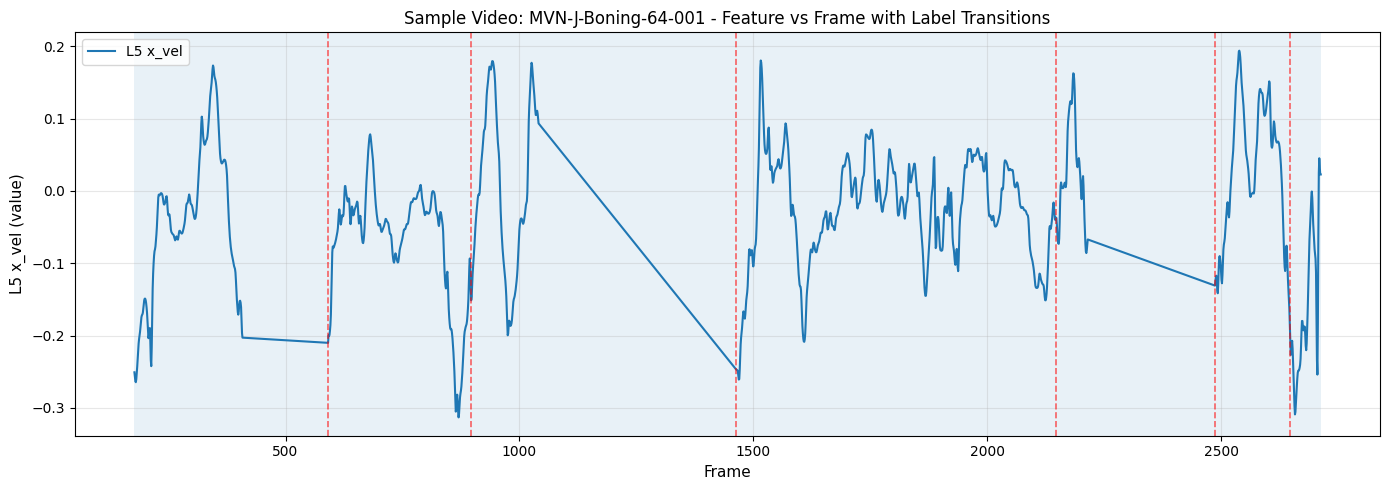

[phase=plot] Red dashed lines indicate label transition points.


In [10]:
import matplotlib.pyplot as plt

print("[phase=plot] Plotting one sample video with label transitions")

# Select first unique video from combined_df
sample_video_id = combined_df["video_id"].unique()[0]
sample_df = combined_df[combined_df["video_id"] == sample_video_id].copy()
sample_df = sample_df.sort_values("Frame").reset_index(drop=True)

print(f"[phase=plot] Sample video: {sample_video_id} ({len(sample_df)} frames)")

# Plot setup
feature_name = "L5 x_vel"  # Choose a sample feature to visualize
fig, ax = plt.subplots(figsize=(14, 5))

# Plot feature value vs Frame
frames = sample_df["Frame"].values
feature_values = sample_df[feature_name].values
ax.plot(frames, feature_values, linewidth=1.5, label=feature_name)

# Mark transition boundaries
transitions = sample_df[sample_df["Label"].diff().fillna(0) != 0]["Frame"].values
for t_frame in transitions:
    ax.axvline(x=t_frame, color='red', linestyle='--', alpha=0.6, linewidth=1.2)

# Shade regions by label
previous_transition = frames[0]
for t_frame in transitions:
    ax.axvspan(previous_transition, t_frame, alpha=0.1)
    previous_transition = t_frame
ax.axvspan(previous_transition, frames[-1], alpha=0.1)

ax.set_xlabel("Frame", fontsize=11)
ax.set_ylabel(f"{feature_name} (value)", fontsize=11)
ax.set_title(f"Sample Video: {sample_video_id} - Feature vs Frame with Label Transitions", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"[phase=plot] Red dashed lines indicate label transition points.")


# Normalize Data


In [11]:
# Normalize data (frame-level) using train frames only
from sklearn.preprocessing import StandardScaler

# Hold-out specific videos for validation (to avoid leakage)
TEST_VIDEO_IDS = ["MVN-J-Boning-90-004", "MVN-S-Slicing-63-001","MVN-S-Boning-89-004"]

# Split by video_id
train_df = combined_df[~combined_df["video_id"].isin(TEST_VIDEO_IDS)].copy()
val_df = combined_df[combined_df["video_id"].isin(TEST_VIDEO_IDS)].copy()

# Fit scaler on train frames only
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])

print("[phase=norm] StandardScaler fit on train frames only")
print("Train stats -> min:", train_df[feature_cols].min().min(),
      "max:", train_df[feature_cols].max().max(),
      "mean:", train_df[feature_cols].mean().mean(),
      "std:", train_df[feature_cols].std().mean())
# print("Val   stats -> min:", val_df[feature_cols].min().min(),
#       "max:", val_df[feature_cols].max().max(),
#       "mean:", val_df[feature_cols].mean().mean(),
#       "std:", val_df[feature_cols].std().mean())


print("[phase=norm] Train per-column min/max:")
train_min = train_df[feature_cols].min()
train_max = train_df[feature_cols].max()
print(pd.DataFrame({"min": train_min, "max": train_max}).to_string())

print("[phase=norm] Val per-column min/max:")
val_min = val_df[feature_cols].min()
val_max = val_df[feature_cols].max()

print(pd.DataFrame({"min": val_min, "max": val_max}).to_string(),
      "max:", val_df[feature_cols].max().max(),
      "mean:", val_df[feature_cols].mean().mean(),
      "std:", val_df[feature_cols].std().mean())




[phase=norm] StandardScaler fit on train frames only
Train stats -> min: -1.505339558219673 max: 76.2201318539774 mean: -3.861631322278197e-18 std: 1.0000023274189742
[phase=norm] Train per-column min/max:
                              min        max
L5_vel_mag              -1.494972   3.494680
L3_vel_mag              -1.497042   3.494182
T12_vel_mag             -1.497141   3.493508
T8_vel_mag              -1.138026  13.004542
Neck_vel_mag            -1.505340   3.493394
Head_vel_mag            -1.156436  11.518482
Right Shoulder_vel_mag  -1.125063  12.551193
Right Upper Arm_vel_mag -1.208779   9.583068
Right Forearm_vel_mag   -1.095725   8.312676
Right Hand_vel_mag      -1.097576   8.919579
Left Shoulder_vel_mag   -1.121484  12.519038
Left Upper Arm_vel_mag  -1.142375   7.757212
Left Forearm_vel_mag    -0.966527   8.568119
Left Hand_vel_mag       -0.947958   6.682775
Right Upper Leg_vel_mag -1.104338  12.582703
Right Lower Leg_vel_mag -0.761643  15.699590
Right Foot_vel_mag      -0.72

## Build Dynamic Windows from Label Transitions


In [ ]:
import numpy as np

print("[phase=windows] Building windows from contiguous runs with label-specific frame skipping")

# Default behavior for labels not listed below.
DEFAULT_WINDOW_SIZE = 60
DEFAULT_WINDOW_STRIDE = 30
DEFAULT_FRAME_SKIP_STEP = 2  # keep every 2nd frame -> skip 1 frame between selected frames

# Label-specific overrides.
# Labels 0, 6, 7, 8: window=60, stride=30, no skip -> sampling step=1.
LABEL_SPECIFIC_RULES = {
    0: {"window_size": 60, "window_stride": 30, "frame_skip_step": 1},
    6: {"window_size": 60, "window_stride": 30, "frame_skip_step": 1},
    7: {"window_size": 60, "window_stride": 30, "frame_skip_step": 1},
    8: {"window_size": 60, "window_stride": 30, "frame_skip_step": 1},
}

if not hasattr(scaler, "mean_"):
    raise RuntimeError("Scaler is not fitted. Run the Normalize Data cell first.")

combined_df_norm = combined_df.copy()
combined_df_norm[feature_cols] = scaler.transform(combined_df[feature_cols])

if not np.isfinite(combined_df_norm[feature_cols].to_numpy()).all():
    raise ValueError("Normalization produced non-finite values. Check feature columns and scaler fit.")

X_windows = []
y_windows = []
window_meta = []
window_lengths = []

for run_idx, run in enumerate(runs):
    label = int(run["label"])

    params = LABEL_SPECIFIC_RULES.get(
        label,
        {
            "window_size": DEFAULT_WINDOW_SIZE,
            "window_stride": DEFAULT_WINDOW_STRIDE,
            "frame_skip_step": DEFAULT_FRAME_SKIP_STEP,
        },
    )

    window_size = int(params["window_size"])
    window_stride = int(params["window_stride"])
    frame_skip_step = int(params["frame_skip_step"])

    run_indices = np.arange(run["start_idx"], run["end_idx"] + 1)
    sampled_indices = run_indices[::frame_skip_step]

    if len(sampled_indices) == 0:
        continue

    if len(sampled_indices) <= window_size:
        idx_chunk = sampled_indices
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(label)
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": label,
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
            "window_size": window_size,
            "window_stride": window_stride,
            "frame_skip_step": frame_skip_step,
        })
        continue

    starts = list(range(0, len(sampled_indices) - window_size + 1, window_stride))

    for start in starts:
        idx_chunk = sampled_indices[start:start + window_size]
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(label)
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": label,
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
            "window_size": window_size,
            "window_stride": window_stride,
            "frame_skip_step": frame_skip_step,
        })

    last_covered = starts[-1] + window_size
    if last_covered < len(sampled_indices):
        idx_chunk = sampled_indices[last_covered:]
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(label)
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": label,
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
            "window_size": window_size,
            "window_stride": window_stride,
            "frame_skip_step": frame_skip_step,
        })

y_windows = np.array(y_windows, dtype=np.int64)
window_meta_df = pd.DataFrame(window_meta)

window_count_per_label = {}
for label in y_windows.tolist():
    window_count_per_label[label] = window_count_per_label.get(label, 0) + 1

print(f"[phase=windows] total_windows={len(X_windows)}")
print("[phase=windows] windows per label:")
for label in sorted(window_count_per_label):
    print(f"  label {label}: {window_count_per_label[label]}")

window_lengths_np = np.array(window_lengths)
short_count = int((window_lengths_np < DEFAULT_WINDOW_SIZE).sum())
print(f"[phase=windows] short_windows(<{DEFAULT_WINDOW_SIZE})={short_count}")
print(
    f"[phase=windows] window length min/median/max = "
    f"{window_lengths_np.min()}/{int(np.median(window_lengths_np))}/{window_lengths_np.max()}"
)

if not window_meta_df.empty:
    print("[phase=windows] Effective sampling settings by label:")
    settings_by_label = (
        window_meta_df[["label", "window_size", "window_stride", "frame_skip_step"]]
        .drop_duplicates()
        .sort_values("label")
    )
    print(settings_by_label.to_string(index=False))

[phase=windows] Building windows from contiguous runs with frame skipping
[phase=windows] total_windows=3551
[phase=windows] windows per label:
  label 0: 996
  label 1: 216
  label 2: 706
  label 3: 287
  label 5: 659
  label 6: 113
  label 7: 84
  label 8: 490
[phase=windows] short_windows(<60)=733
[phase=windows] window length min/median/max = 1/60/60


In [13]:
import numpy as np

print("[phase=split] Split windows by TEST_VIDEO_IDS and pad to length 60")

train_mask = ~window_meta_df["video_id"].isin(TEST_VIDEO_IDS)
val_mask = window_meta_df["video_id"].isin(TEST_VIDEO_IDS)

train_indices = np.where(train_mask.to_numpy())[0]
val_indices = np.where(val_mask.to_numpy())[0]

X_train_list = [X_windows[i] for i in train_indices]
y_train_all = y_windows[train_indices]
X_val_list = [X_windows[i] for i in val_indices]
y_val = y_windows[val_indices]

def pad_windows_to_60(window_list, target_len=60):
    padded = []
    for arr in window_list:
        if arr.shape[0] == target_len:
            padded.append(arr)
        elif arr.shape[0] < target_len:
            pad_rows = target_len - arr.shape[0]
            pad_block = np.zeros((pad_rows, arr.shape[1]), dtype=arr.dtype)
            padded.append(np.vstack([arr, pad_block]))
        else:
            padded.append(arr[:target_len])
    return np.stack(padded, axis=0)

X_train_all = pad_windows_to_60(X_train_list, target_len=60)
X_val = pad_windows_to_60(X_val_list, target_len=60)

print(f"[phase=split] Train windows: {X_train_all.shape}, y_train: {y_train_all.shape}")
print(f"[phase=split] Val windows:   {X_val.shape}, y_val:   {y_val.shape}")

[phase=split] Split windows by TEST_VIDEO_IDS and pad to length 60
[phase=split] Train windows: (3297, 60, 45), y_train: (3297,)
[phase=split] Val windows:   (254, 60, 45), y_val:   (254,)


# Improvements


## Train Test Split

In [14]:
# Use full train windows (no window-level split)
X_train, y_train = X_train_all, y_train_all

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Val   X:", X_val.shape, "Val   y:", y_val.shape)



Train X: (3297, 60, 45) Train y: (3297,)
Val   X: (254, 60, 45) Val   y: (254,)


## Loss Function (Categorical Focal or CrossEntropy)

In [15]:
# Switchable loss for multiclass classification: "focal" or "ce"
import torch
import torch.nn as nn
import torch.nn.functional as F

class CategoricalFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_weight = focal_weight * alpha_t

        loss = focal_weight * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

loss_type = "focal"  # options: "focal", "ce"

if loss_type == "focal":
    focal_gamma = 2.0
    criterion = CategoricalFocalLoss(gamma=focal_gamma, alpha=None, reduction="mean")
    print(f"[phase=loss] Using CategoricalFocalLoss (gamma={focal_gamma})")
elif loss_type == "ce":
    criterion = nn.CrossEntropyLoss()
    print("[phase=loss] Using CrossEntropyLoss")
else:
    raise ValueError("loss_type must be one of: 'focal', 'ce'")

[phase=loss] Using CategoricalFocalLoss (gamma=2.0)


## Label Encoding & Class Balance (No Cutting)

In [16]:
# Keep original sparse labels for reporting, encode to contiguous indices for training
y_train_original = y_train_all.astype(np.int64)
y_val_original = y_val.astype(np.int64)

class_labels = sorted(np.unique(np.concatenate([y_train_original, y_val_original])).astype(int).tolist())
label_to_index = {label: idx for idx, label in enumerate(class_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

y_train = np.array([label_to_index[int(v)] for v in y_train_original], dtype=np.int64)
y_val = np.array([label_to_index[int(v)] for v in y_val_original], dtype=np.int64)

print("[phase=labels] Multiclass labels ready (cutting removed)")
print(f"Original labels kept for reports: {class_labels}")
print(f"Encoded class indices: {sorted(index_to_label.keys())}")
print(f"y_train unique indices: {np.unique(y_train)}")
print(f"y_val unique indices: {np.unique(y_val)}")

[phase=labels] Multiclass labels ready (cutting removed)
Original labels kept for reports: [0, 1, 2, 3, 5, 6, 7, 8]
Encoded class indices: [0, 1, 2, 3, 4, 5, 6, 7]
y_train unique indices: [0 1 2 3 4 5 6 7]
y_val unique indices: [0 1 2 3 4 5 6 7]


In [17]:
import numpy as np

print("[phase=dataset] No SMOTE/undersampling; using original multiclass windows")

# Keep original training windows (no resampling)
X_train_aug = X_train_all.astype(np.float32)
y_train_aug = y_train.astype(np.int64)

class_vals, class_counts = np.unique(y_train_aug, return_counts=True)
print("Encoded class counts (train):", dict(zip(class_vals.tolist(), class_counts.tolist())))
print("Original label mapping:", index_to_label)
print(f"[phase=dataset] X_train_aug shape: {X_train_aug.shape}")
print(f"[phase=dataset] y_train_aug shape: {y_train_aug.shape}")

[phase=dataset] No SMOTE/undersampling; using original multiclass windows
Encoded class counts (train): {0: 975, 1: 181, 2: 647, 3: 254, 4: 604, 5: 107, 6: 64, 7: 465}
Original label mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 5, 5: 6, 6: 7, 7: 8}
[phase=dataset] X_train_aug shape: (3297, 60, 45)
[phase=dataset] y_train_aug shape: (3297,)


# Model Building

In [23]:
import torch
import torch.nn as nn
from tqdm import tqdm # Optional: for progress bars during epochs

print("[phase=model] Defining BiLSTM Architecture")

# 1. Define the BiLSTM Model Class
class ActivityBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.4):
        super(ActivityBiLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Single FC block: LN -> Linear -> Dropout -> ReLU
        self.fc_ln = nn.LayerNorm(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # Final output layer
        self.fc_out = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length/window_size, input_size/features)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Temporal pooling over time dimension (mean pooling)
        out = out.mean(dim=1)

        # FC block
        out = self.fc_ln(out)
        out = self.fc(out)
        out = self.dropout(out)
        out = self.relu(out)

        # Final output layer
        out = self.fc_out(out)
        return out


[phase=model] Defining BiLSTM Architecture


# Hyperparameters

In [24]:
# Instantiate model, criterion, optimizer
input_size = X_train_aug.shape[-1]
num_classes = len(class_labels)

hidden_size = 128
num_layers = 1
dropout = 0.4

model = ActivityBiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

print(f"[phase=model] Model params: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}, num_classes={num_classes}")
print(f"[phase=model] Original class labels (no cutting): {class_labels}")
print("[phase=model] Optimizer: Adam")

[phase=model] Model params: input_size=45, hidden_size=128, num_layers=1, num_classes=8
[phase=model] Original class labels (no cutting): [0, 1, 2, 3, 5, 6, 7, 8]
[phase=model] Optimizer: Adam


# Training

In [25]:
# Train loop with early stopping, checkpoint, and ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader

# Convert to torch tensors
X_train_t = torch.tensor(X_train_aug, dtype=torch.float32)
y_train_t = torch.tensor(y_train_aug, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# Reuse validation set for final evaluation
X_test_t = X_val_t
y_test_t = y_val_t

# drop_last=True avoids singleton last-batch edge cases during training
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

# Callbacks (manual implementations)
early_stopping_patience = 10
best_val_loss = float('inf')
patience_counter = 0

checkpoint_path = PROJECT_ROOT / "notebook" / "best_bilstm_except_4.pt"

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

prev_lr = optimizer.param_groups[0]['lr']

def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

num_epochs = 30

for epoch in range(1, num_epochs + 1):
    # Train
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        train_acc += accuracy_from_logits(logits, yb) * xb.size(0)

    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)

    # Validate
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            val_acc += accuracy_from_logits(logits, yb) * xb.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    # Reduce LR on plateau
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != prev_lr:
        print(f"[lr] {prev_lr:.6f} -> {new_lr:.6f}")
        prev_lr = new_lr

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping + checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

Epoch 01 | Train Loss: 1.0049 | Train Acc: 0.4774 | Val Loss: 1.0127 | Val Acc: 0.4803
Epoch 02 | Train Loss: 0.6792 | Train Acc: 0.5918 | Val Loss: 0.9152 | Val Acc: 0.5236
Epoch 03 | Train Loss: 0.6003 | Train Acc: 0.6503 | Val Loss: 0.8657 | Val Acc: 0.5433
Epoch 04 | Train Loss: 0.5539 | Train Acc: 0.6570 | Val Loss: 0.8364 | Val Acc: 0.5354
Epoch 05 | Train Loss: 0.5260 | Train Acc: 0.6755 | Val Loss: 0.8051 | Val Acc: 0.5669
Epoch 06 | Train Loss: 0.4960 | Train Acc: 0.6934 | Val Loss: 0.7863 | Val Acc: 0.5669
Epoch 07 | Train Loss: 0.4676 | Train Acc: 0.7022 | Val Loss: 0.7408 | Val Acc: 0.5591
Epoch 08 | Train Loss: 0.4536 | Train Acc: 0.7088 | Val Loss: 0.7304 | Val Acc: 0.5630
Epoch 09 | Train Loss: 0.4331 | Train Acc: 0.7279 | Val Loss: 0.7171 | Val Acc: 0.5748
Epoch 10 | Train Loss: 0.4090 | Train Acc: 0.7428 | Val Loss: 0.6824 | Val Acc: 0.5748
Epoch 11 | Train Loss: 0.4038 | Train Acc: 0.7316 | Val Loss: 0.6641 | Val Acc: 0.5748
Epoch 12 | Train Loss: 0.3933 | Train Acc: 

# Evaluation

[phase=eval] Evaluating multiclass model on validation videos
Test Loss: 0.6144 | Test Acc: 0.5787


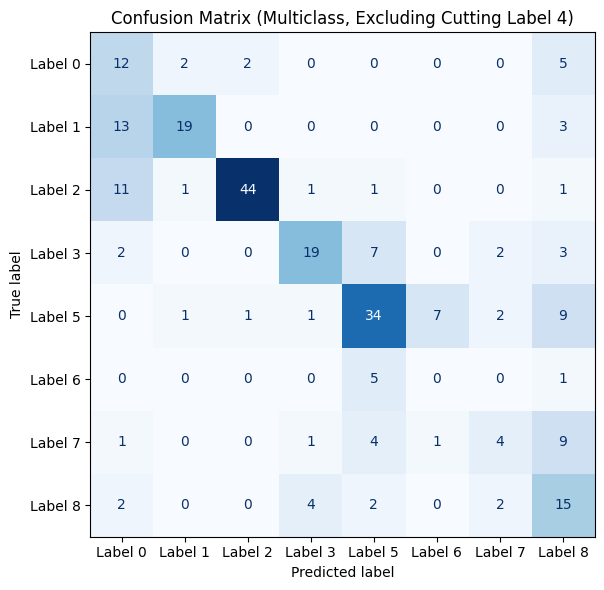


Classification report (original labels):
              precision    recall  f1-score   support

           0       0.29      0.57      0.39        21
           1       0.83      0.54      0.66        35
           2       0.94      0.75      0.83        59
           3       0.73      0.58      0.64        33
           5       0.64      0.62      0.63        55
           6       0.00      0.00      0.00         6
           7       0.40      0.20      0.27        20
           8       0.33      0.60      0.42        25

    accuracy                           0.58       254
   macro avg       0.52      0.48      0.48       254
weighted avg       0.65      0.58      0.60       254



In [26]:
# Test evaluation (held-out videos)
print("[phase=eval] Evaluating multiclass model on validation videos")

# Load best checkpoint if available
if checkpoint_path.exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()

test_loss = 0.0
test_acc = 0.0

all_preds_idx = []
all_targets_idx = []

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        preds = torch.argmax(logits, dim=1)

        test_loss += loss.item() * xb.size(0)
        test_acc += (preds == yb).float().mean().item() * xb.size(0)

        all_preds_idx.append(preds.detach().cpu())
        all_targets_idx.append(yb.detach().cpu())

if len(test_loader.dataset) > 0:
    test_loss /= len(test_loader.dataset)
    test_acc /= len(test_loader.dataset)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

    y_true_idx = torch.cat(all_targets_idx).numpy().astype(int)
    y_pred_idx = torch.cat(all_preds_idx).numpy().astype(int)

    # Convert back to original sparse labels for reporting
    y_true = np.array([index_to_label[int(i)] for i in y_true_idx], dtype=int)
    y_pred = np.array([index_to_label[int(i)] for i in y_pred_idx], dtype=int)

    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    display_labels = [f"Label {label}" for label in class_labels]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title("Confusion Matrix (Multiclass, Excluding Cutting Label 4)")
    plt.tight_layout()
    plt.show()

    print("\nClassification report (original labels):")
    print(classification_report(y_true, y_pred, labels=class_labels, zero_division=0))
else:
    print("[warning] No test samples after filtering.")

In [ ]:
import numpy as np

print("[phase=eval] Multiclass distribution (excluding cutting label 4)")

train_original_counts = dict(zip(*np.unique(y_train_original, return_counts=True)))
val_original_counts = dict(zip(*np.unique(y_val_original, return_counts=True)))
val_total = int(len(y_val_original))

print(f"{'Original Label':<16} {'Train':>8} {'Val':>8} {'Val%':>8}")
print("-" * 46)
for label in class_labels:
    train_count = int(train_original_counts.get(label, 0))
    val_count = int(val_original_counts.get(label, 0))
    val_pct = (val_count / val_total * 100.0) if val_total > 0 else 0.0
    print(f"{label:<16} {train_count:>8} {val_count:>8} {val_pct:>7.1f}%")

print("\nEncoded index -> original label mapping:")
for idx in sorted(index_to_label.keys()):
    print(f"  {idx} -> {index_to_label[idx]}")

[phase=eval] Binary class distribution (cutting=1, non-cutting=0)
Class                 Train      Val     Val%
----------------------------------------------
Cutting (1)            3519      395    59.3%
Non-cutting (0)        3450      271    40.7%
